In [1]:
!apt-get install -y fonts-nanum > /dev/null

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

from xgboost import XGBRegressor

DATA_DIR = '/content/drive/MyDrive/power_forecast/'

train_df = pd.read_csv(DATA_DIR + 'train_fe.csv')

print('로드 완료')
print('train shape:', train_df.shape)

Mounted at /content/drive
로드 완료
train shape: (204000, 35)


In [2]:
result_path = DATA_DIR + 'experiment_results.csv'

existing_results = pd.read_csv(result_path)
print('=== 기존 실험 결과 ===')
print(existing_results.to_string(index=False))

score_exp4 = existing_results[existing_results['실험번호'] == 4]['SMAPE'].values[0]
score_exp5 = existing_results[existing_results['실험번호'] == 5]['SMAPE'].values[0]

best_params = {'max_depth': 8, 'min_child_weight': 1,
               'subsample': 0.9, 'colsample_bytree': 0.9}

=== 기존 실험 결과 ===
 실험번호                 실험명     SMAPE       개선폭                                                                                         비고
    0 대회_Baseline_XGBoost 24.014000  0.000000                                                     대회 제공 Baseline, Feature Engineering 없음
    1          FE_XGBoost  8.424200 15.589800                                                                  Feature Engineering 추가 효과
    2         LightGBM_전체  9.388100 -0.963900                                                                            XGBoost보다 성능 낮음
    3         유형별_XGBoost  7.257900  2.130200                                                                            유형별 모델 분리 효과 확인
    4      유형별_XGBoost_튜닝  6.889891  0.368009 최적파라미터: {'max_depth': 8, 'min_child_weight': 1, 'subsample': 0.9, 'colsample_bytree': 0.9}
    5      건물별_XGBoost_튜닝  7.029944 -0.140053                                                                        100개 건물 각각 개별 모델 학습
    7            Ensembl

In [3]:
TRAIN_FEATURES = [
    '건물번호', 'building_type_enc',
    '연면적(m2)', '냉방면적(m2)', '태양광용량(kW)', 'ESS저장용량(kWh)', 'PCS용량(kW)',
    'has_solar', 'has_ess', 'is_IDC',
    'month', 'day', 'hour', 'weekday', 'is_weekend',
    'hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos',
    '기온(°C)', '강수량(mm)', '풍속(m/s)', '습도(%)', 'THI', 'CDH',
    'building_hour_mean', 'building_weekday_mean', 'building_mean',
    '일조(hr)', '일사(MJ/m2)',
]
TARGET = '전력소비량(kWh)'

def smape(true, pred):
    true, pred = np.array(true), np.array(pred)
    return np.mean(2 * np.abs(true - pred) / (np.abs(true) + np.abs(pred))) * 100

val_mask_all   = train_df['일시'] >= '20240818 00'
train_mask_all = train_df['일시'] < '20240818 00'

print(f'학습 데이터: {train_mask_all.sum():,}행')
print(f'검증 데이터: {val_mask_all.sum():,}행')

학습 데이터: 187,200행
검증 데이터: 16,800행


In [4]:
# 앙상블을 위해 실험 4 예측값 재생성
preds_type = np.zeros(len(train_df))

for btype in train_df['건물유형'].unique():
    train_mask = (train_df['일시'] < '20240818 00') & (train_df['건물유형'] == btype)
    val_mask   = (train_df['일시'] >= '20240818 00') & (train_df['건물유형'] == btype)

    tx = train_df[TRAIN_FEATURES][train_mask]
    ty = train_df[TARGET][train_mask]
    vx = train_df[TRAIN_FEATURES][val_mask]
    vy = train_df[TARGET][val_mask]

    if len(tx) == 0 or len(vx) == 0:
        continue

    model = XGBRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        n_jobs=-1,
        random_state=42,
        early_stopping_rounds=50,
        eval_metric='mae',
        **best_params
    )
    model.fit(tx, ty, eval_set=[(vx, vy)], verbose=False)
    preds_type[val_mask.values] = model.predict(vx)
    print(f'  {btype} 학습 완료')

score_type = smape(
    train_df[TARGET][val_mask_all],
    preds_type[val_mask_all.values]
)
print(f'\n유형별 모델 SMAPE: {score_type:.4f} (실험 4: {score_exp4})')

  호텔 학습 완료
  상용 학습 완료
  병원 학습 완료
  학교 학습 완료
  건물기타 학습 완료
  아파트 학습 완료
  연구소 학습 완료
  백화점 학습 완료
  IDC(전화국) 학습 완료
  공공 학습 완료

유형별 모델 SMAPE: 6.8899 (실험 4: 6.889890997755242)


In [5]:
# 앙상블을 위해 실험 5 예측값 재생성
preds_building = np.zeros(len(train_df))

for bnum in sorted(train_df['건물번호'].unique()):
    train_mask = (train_df['일시'] < '20240818 00') & (train_df['건물번호'] == bnum)
    val_mask   = (train_df['일시'] >= '20240818 00') & (train_df['건물번호'] == bnum)

    tx = train_df[TRAIN_FEATURES][train_mask]
    ty = train_df[TARGET][train_mask]
    vx = train_df[TRAIN_FEATURES][val_mask]
    vy = train_df[TARGET][val_mask]

    if len(tx) == 0 or len(vx) == 0:
        continue

    model = XGBRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        n_jobs=-1,
        random_state=42,
        early_stopping_rounds=50,
        eval_metric='mae',
        **best_params
    )
    model.fit(tx, ty, eval_set=[(vx, vy)], verbose=False)
    preds_building[val_mask.values] = model.predict(vx)

score_building = smape(
    train_df[TARGET][val_mask_all],
    preds_building[val_mask_all.values]
)
print(f'건물별 모델 SMAPE: {score_building:.4f} (실험 5: {score_exp5})')

건물별 모델 SMAPE: 7.0299 (실험 5: 7.02994372280025)


In [6]:
# 최적 가중치 탐색
# 유형별 모델이 더 좋으므로 유형별에 더 높은 가중치를 줄 것으로 예상
# 0.1 단위로 탐색해서 최적 비율 찾기

best_w      = None
best_score  = float('inf')
results_w   = []

for w in np.arange(0.1, 1.0, 0.1):
    # w = 유형별 모델 가중치
    # (1-w) = 건물별 모델 가중치
    ensemble_pred = w * preds_type + (1 - w) * preds_building
    score = smape(
        train_df[TARGET][val_mask_all],
        ensemble_pred[val_mask_all.values]
    )
    results_w.append({'유형별_가중치': round(w, 1),
                      '건물별_가중치': round(1-w, 1),
                      'SMAPE': score})

    if score < best_score:
        best_score = score
        best_w     = round(w, 1)

results_w_df = pd.DataFrame(results_w)
print('=== 가중치별 SMAPE ===')
print(results_w_df.to_string(index=False))
print(f'\n최적 가중치 유형별: {best_w}, 건물별: {round(1-best_w, 1)}')
print(f'앙상블 최적 SMAPE: {best_score:.4f}')

=== 가중치별 SMAPE ===
 유형별_가중치  건물별_가중치    SMAPE
     0.1      0.9 6.929828
     0.2      0.8 6.851516
     0.3      0.7 6.793835
     0.4      0.6 6.754493
     0.5      0.5 6.734281
     0.6      0.4 6.732402
     0.7      0.3 6.748304
     0.8      0.2 6.779263
     0.9      0.1 6.826889

최적 가중치 유형별: 0.6, 건물별: 0.4
앙상블 최적 SMAPE: 6.7324


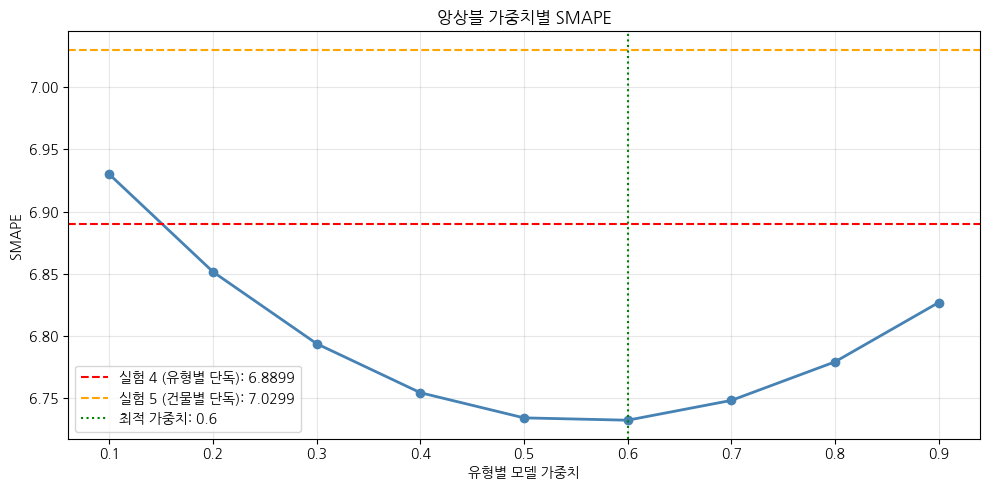

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(results_w_df['유형별_가중치'],
         results_w_df['SMAPE'],
         marker='o', linewidth=2, color='steelblue')
plt.axhline(y=score_exp4, color='red', linestyle='--',
            label=f'실험 4 (유형별 단독): {score_exp4:.4f}')
plt.axhline(y=score_exp5, color='orange', linestyle='--',
            label=f'실험 5 (건물별 단독): {score_exp5:.4f}')
plt.axvline(x=best_w, color='green', linestyle=':',
            label=f'최적 가중치: {best_w}')
plt.title('앙상블 가중치별 SMAPE')
plt.xlabel('유형별 모델 가중치')
plt.ylabel('SMAPE')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

저장 완료: building_35_IDC(전화국).png


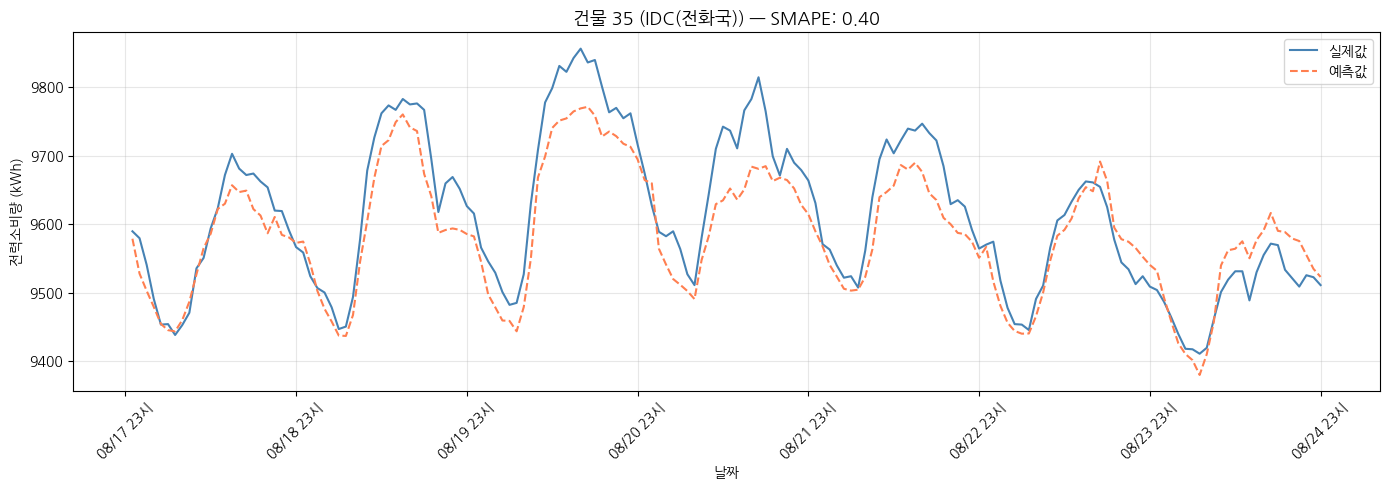

저장 완료: building_41_상용.png


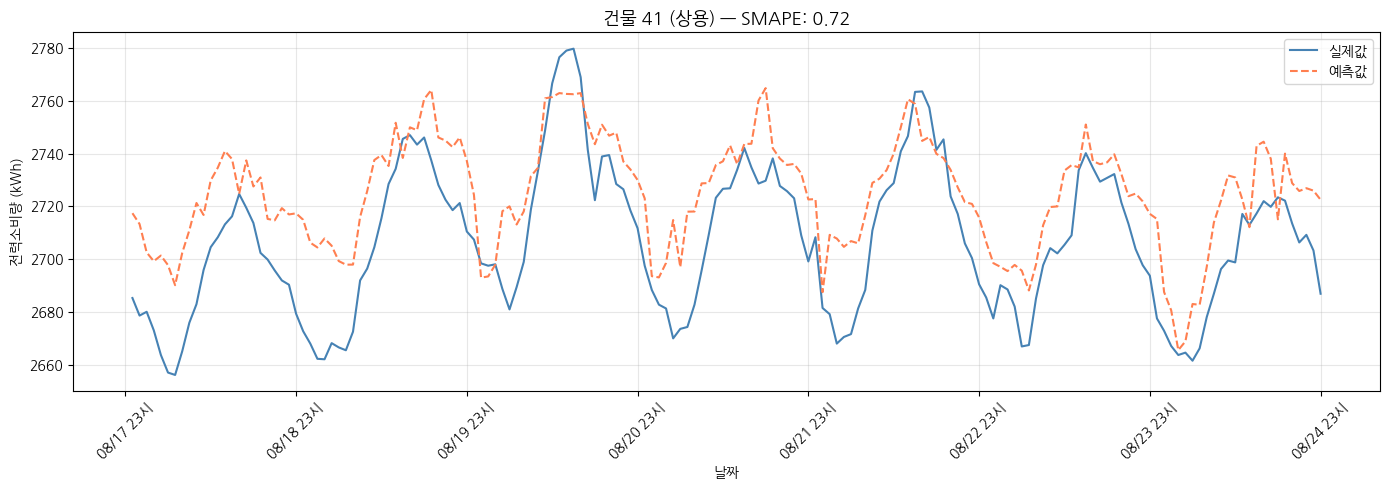

저장 완료: building_55_학교.png


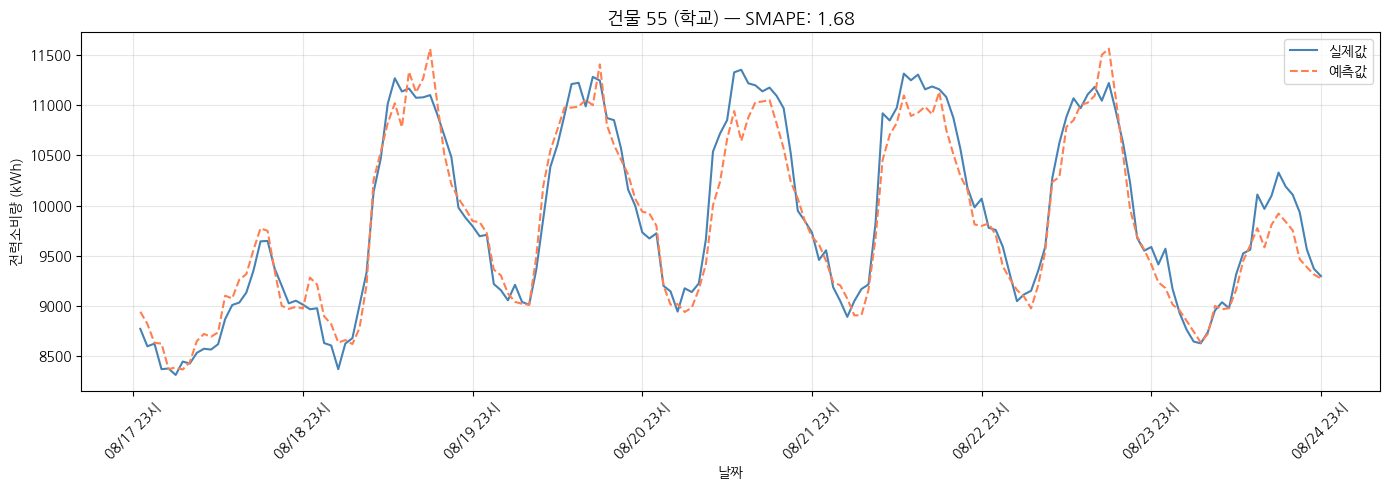

저장 완료: building_7_건물기타.png


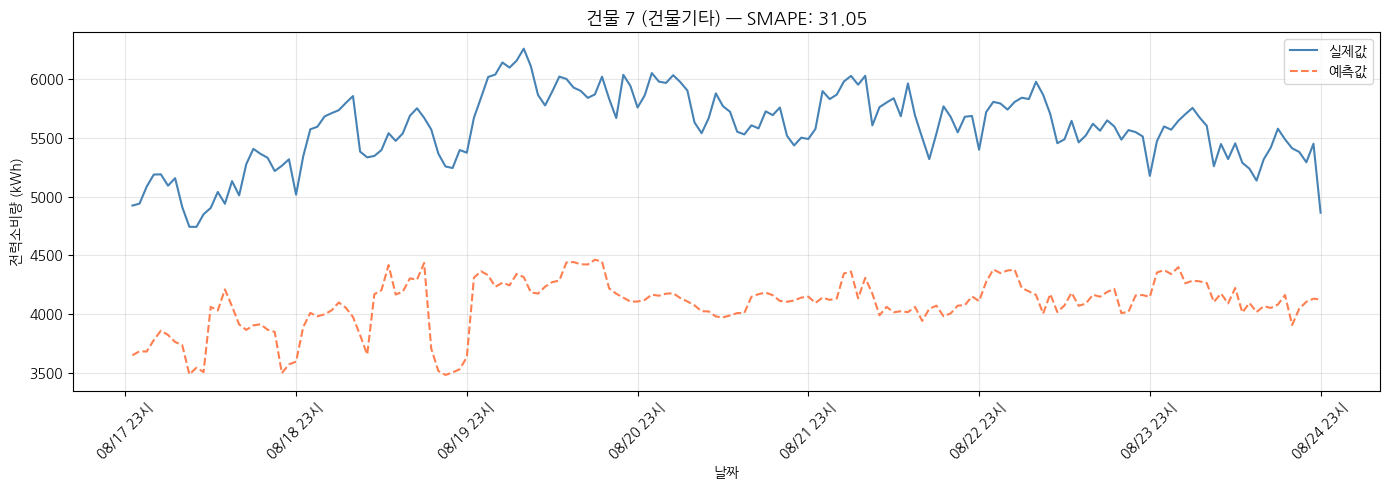


전체 저장 경로: /content/drive/MyDrive/power_forecast/images/


In [9]:
# 실제 vs 예측 비교 시각화
# 건물 유형별로 대표 건물 1개씩 선택해서 비교
import os
import matplotlib.dates as mdates

save_path = DATA_DIR + 'images/'
os.makedirs(save_path, exist_ok=True)

representative_buildings = {
    35: 'IDC(전화국)',
    41: '상용',
    55: '학교',
    7 : '건물기타',
}

for bnum, btype in representative_buildings.items():
    val_mask = (train_df['일시'] >= '20240818 00') & \
               (train_df['건물번호'] == bnum)

    # 날짜 추출
    dates     = pd.to_datetime(
                    train_df[val_mask]['일시'],
                    format='%Y%m%d %H'
                )
    true_vals = train_df[TARGET][val_mask].values
    pred_vals = (best_w * preds_type[val_mask.values] +
                 (1 - best_w) * preds_building[val_mask.values])

    b_smape = smape(true_vals, pred_vals)

    fig, ax = plt.subplots(figsize=(14, 5))

    ax.plot(dates, true_vals,
            label='실제값', color='steelblue', linewidth=1.5)
    ax.plot(dates, pred_vals,
            label='예측값', color='coral',
            linewidth=1.5, linestyle='--')

    # x축 날짜 포맷 설정
    ax.xaxis.set_major_formatter(
        mdates.DateFormatter('%m/%d %H시')
    )
    ax.xaxis.set_major_locator(
        mdates.HourLocator(interval=24)  # 24시간 간격으로 표시
    )
    plt.xticks(rotation=45)

    ax.set_title(f'건물 {bnum} ({btype}) — SMAPE: {b_smape:.2f}',
                 fontsize=13)
    ax.set_xlabel('날짜')
    ax.set_ylabel('전력소비량 (kWh)')
    ax.legend(loc='upper right')
    ax.grid(alpha=0.3)

    plt.tight_layout()

    # 건물별 개별 파일로 저장
    filename = f'building_{bnum}_{btype}.png'
    plt.savefig(save_path + filename,
                dpi=150,
                bbox_inches='tight',
                facecolor='white')
    print(f'저장 완료: {filename}')
    plt.show()

print(f'\n전체 저장 경로: {save_path}')

실험 7 결과 저장 완료

실험 결과 비교
실험명                                 SMAPE      개선폭
----------------------------------------------------
대회_Baseline_XGBoost               24.0140  +0.0000
FE_XGBoost                         8.4242 +15.5898
LightGBM_전체                        9.3881  -0.9639
유형별_XGBoost                        7.2579  +2.1302
유형별_XGBoost_튜닝                     6.8899  +0.3680
건물별_XGBoost_튜닝                     7.0299  -0.1401
Ensemble                           6.7324  +0.1575


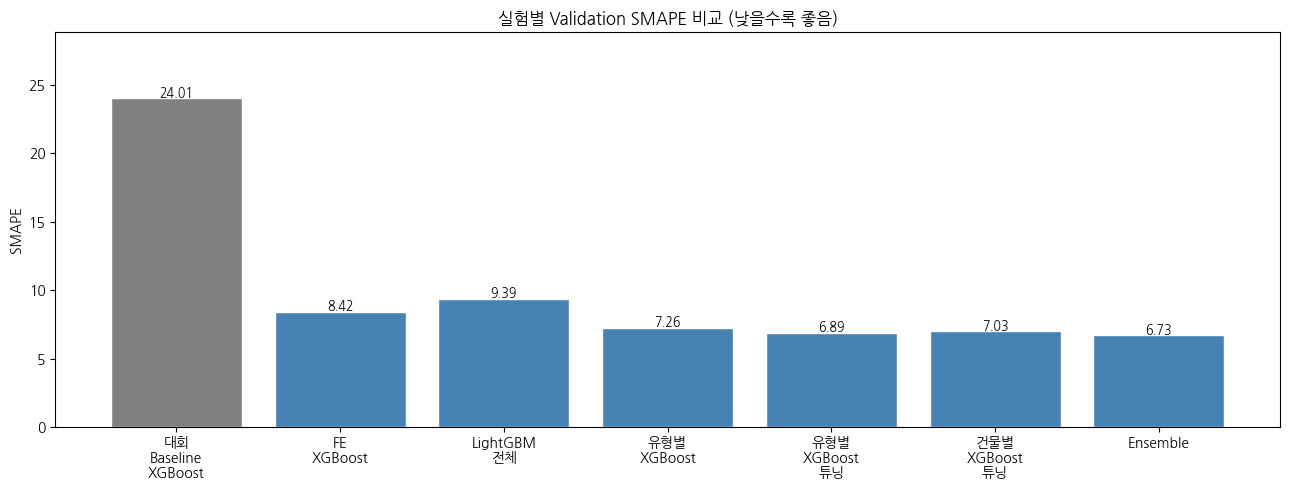

In [ ]:
new_result = pd.DataFrame([{
    '실험번호': 7,
    '실험명': 'Ensemble',
    'SMAPE': best_score,
    '개선폭': score_exp4 - best_score,
    '비고': f'유형별:{best_w} + 건물별:{round(1-best_w,1)} 가중평균'
}])

combined = pd.concat([existing_results, new_result], ignore_index=True)
combined = combined.drop_duplicates(subset='실험번호', keep='last')
combined = combined.sort_values('실험번호').reset_index(drop=True)
combined.to_csv(result_path, index=False)

print('실험 7 결과 저장 완료')
print()

# 비교표
print('=' * 52)
print('실험 결과 비교')
print('=' * 52)
print(f'{"실험명":<32} {"SMAPE":>8} {"개선폭":>8}')
print('-' * 52)
for _, row in combined.iterrows():
    print(f'{row["실험명"]:<32} {row["SMAPE"]:>8.4f} {row["개선폭"]:>+8.4f}')
print('=' * 52)

# 시각화
plt.figure(figsize=(13, 5))
labels = [name.replace('_', '\n') for name in combined['실험명']]
scores = combined['SMAPE'].tolist()
colors = ['gray'] + ['steelblue'] * (len(combined) - 1)

bars = plt.bar(labels, scores, color=colors, edgecolor='white')
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.1,
             f'{score:.2f}', ha='center', fontsize=9, fontweight='bold')

plt.title('실험별 Validation SMAPE 비교 (낮을수록 좋음)')
plt.ylabel('SMAPE')
plt.ylim(0, max(scores) * 1.2)
plt.tight_layout()
plt.show()